In [136]:
from seaborn.cm import rocket
import pandas  as  pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as  sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score 
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier




In [ ]:
data  = pd.read_csv("Churn_dataset.csv")


In [ ]:
df = data 
df.head()


In [ ]:
df.info()


In [ ]:
df.isnull().sum()


In [ ]:
df.describe()


In [ ]:
df['SeniorCitizen'].unique()
df['PaymentMethod'].unique()


In [ ]:
df['gender']=df['gender'].map({'Male':1,'Female':0})


In [ ]:
pd.crosstab(df['gender'],df['Churn'],normalize='index')


In [ ]:
pd.crosstab(df['SeniorCitizen'],df['Churn'],normalize='index')


In [ ]:
df.groupby('Churn')['tenure'].mean()


In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
# Aur missing values ko 0 ki jagah mean ya median se fill karna better ho sakta hai:
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())


In [ ]:
# Har service column ke 'Yes' ko 1 aur baaki ko 0 mankar sum karenge
service_cols = ['PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 
                'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

# Naya column: Total number of active services
df['TotalServices'] = (df[service_cols] == 'Yes').sum(axis=1)


In [ ]:
df['Churn'] =  df['Churn'].map({"Yes":1,'No':0})


In [ ]:
binary_cols = ['Partner','Dependents','PhoneService','PaperlessBilling']
for i in binary_cols:
    df[i]=df[i].map({'Yes':1,'No':0})


In [ ]:
df_num = df.select_dtypes(include=['int64','float64','int32'])


In [ ]:
plt.figure(figsize=(12,8))
correlation_matrix = df_num.corr()
sns.heatmap(correlation_matrix,annot=True,
cmap = 'coolwarm',fmt ='.2f',linewidth = 0.5)
plt.title('correlation matrix')
plt.show()
df.head()




In [ ]:
def tenure_group(t):
    if t <= 12: return '0-12_Months'
    elif t <= 24: return '13-24_Months'
    elif t <= 48: return '25-48_Months'
    else: return 'Over_48_Months'
    
df['Tenure_Group'] = df['tenure'].apply(tenure_group)
df.head()


In [ ]:
df.isnull().sum()
df.duplicated().sum()
sns.boxplot(x=df['MonthlyCharges'])
df['MonthlyCharges'].describe()
df.info()


In [ ]:
df.drop('customerID',axis=1,inplace=True )


In [ ]:
print(df.groupby('Partner')['Churn'].mean())
print(df.groupby('Dependents')['Churn'].mean())
print(df.groupby('gender')['Churn'].mean())




In [ ]:
df.drop('gender',axis=1,inplace=True)


In [ ]:
print(df.groupby('SeniorCitizen')['Churn'].mean())


In [ ]:

def get_relation_status(row):
    if  row['Partner'] == 0 and row['Dependents']==0:
        return "solo"
    elif row ['Partner']==1 and row['Dependents'] ==0 :
        return 'Partner Only'
    else:
        return 'Family'


In [ ]:
df['Relationship_status'] = df.apply(get_relation_status,axis = 1)

df.head()


In [ ]:
sns.pairplot(df,vars=['tenure','MonthlyCharges','TotalCharges'],hue='Churn',palette='Set2')
plt.show()






C:\Users\paiks\AppData\Local\Temp\ipykernel_3052\1905746414.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn',y=col,data=df,palette = 'Set2')
C:\Users\paiks\AppData\Local\Temp\ipykernel_3052\1905746414.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn',y=col,data=df,palette = 'Set2')
C:\Users\paiks\AppData\Local\Temp\ipykernel_3052\1905746414.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn',y=col,data=df,palette = 'Set2')


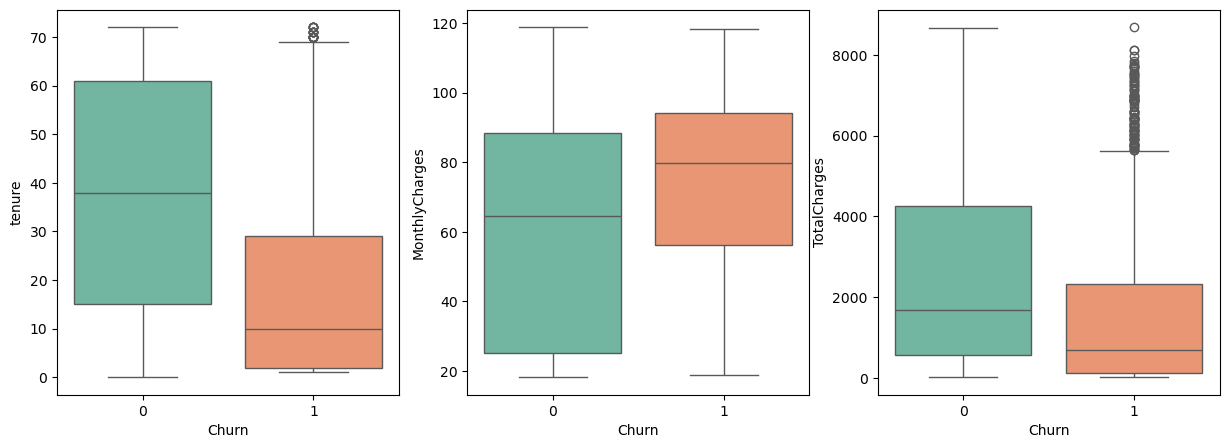

In [98]:

number_col  =  ['tenure',"MonthlyCharges",'TotalCharges']
plt.figure(figsize=(15,5))
for i, col in enumerate(number_col,1):
    plt.subplot(1,3,i)
    sns.boxplot(x='Churn',y=col,data=df,palette = 'Set2')
plt.show()





C:\Users\paiks\AppData\Local\Temp\ipykernel_3052\536023163.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn',data = df ,palette='Set2')


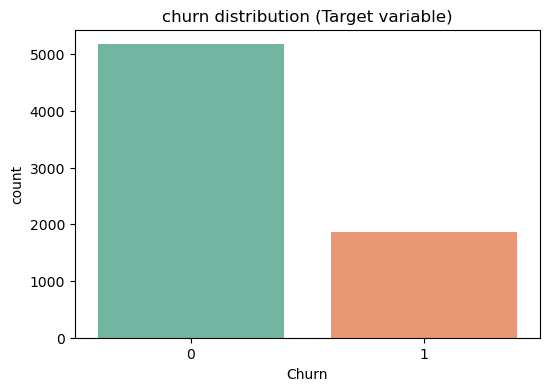

Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64


In [99]:

plt.figure(figsize=(6,4))
sns.countplot(x='Churn',data = df ,palette='Set2')
plt.title("churn distribution (Target variable)")
plt.show()

print(df['Churn'].value_counts(normalize = True)*100)


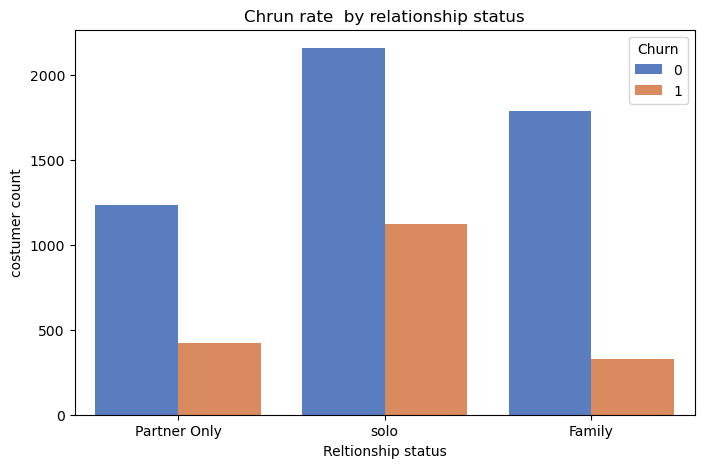

Churn                        0          1
Relationship_status                      
Family               84.549763  15.450237
Partner Only         74.591652  25.408348
solo                 65.762195  34.237805


In [100]:
plt.figure(figsize=(8,5))
sns.countplot(x = 'Relationship_status',data = df ,hue='Churn',palette='muted')
plt.title("Chrun rate  by relationship status")
plt.xlabel('Reltionship status')
plt.ylabel('costumer count')
plt.show()

print((pd.crosstab(df['Relationship_status'],df['Churn'],normalize='index')*100))


In [101]:
# Dono columns 'Yes' hain ya nahi, hum check karenge
df['Streaming_Fanatic'] = ((df['StreamingTV'] == 'Yes') & (df['StreamingMovies'] == 'Yes')).map({True: 'Fanatic', False: 'Regular/Non-User'})
df['Streaming_Fanatic'].head()


0    Regular/Non-User
1    Regular/Non-User
2    Regular/Non-User
3    Regular/Non-User
4    Regular/Non-User
Name: Streaming_Fanatic, dtype: object

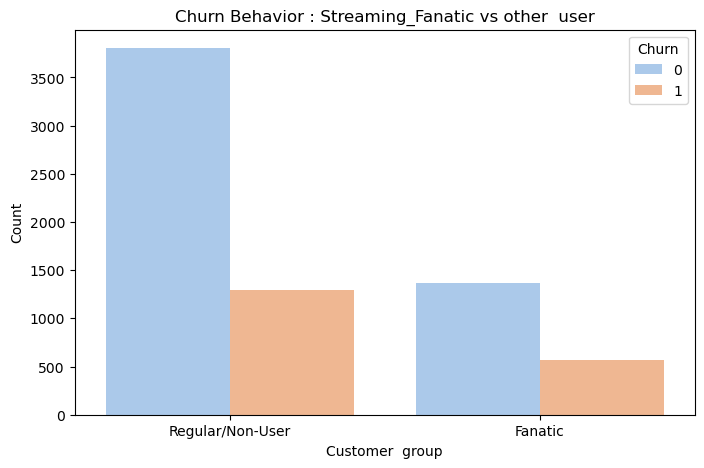

Churn                      0          1
Streaming_Fanatic                      
Fanatic            70.567010  29.432990
Regular/Non-User   74.563982  25.436018


In [102]:
plt.figure(figsize=(8,5))
sns.countplot(data = df,x='Streaming_Fanatic',hue = 'Churn',palette='pastel')
plt.title("Churn Behavior : Streaming_Fanatic vs other  user")
plt.xlabel("Customer  group")
plt.ylabel('Count')
plt.show()
print(pd.crosstab(df['Streaming_Fanatic'],df['Churn'],normalize='index')*100)


C:\Users\paiks\AppData\Local\Temp\ipykernel_3052\4017690154.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data = df,x='Churn',y='MonthlyCharges',palette = 'Set2',inner = 'quartile')
C:\Users\paiks\AppData\Local\Temp\ipykernel_3052\4017690154.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data = df ,x='Churn',y='tenure',palette='Set2',inner = 'quartile')


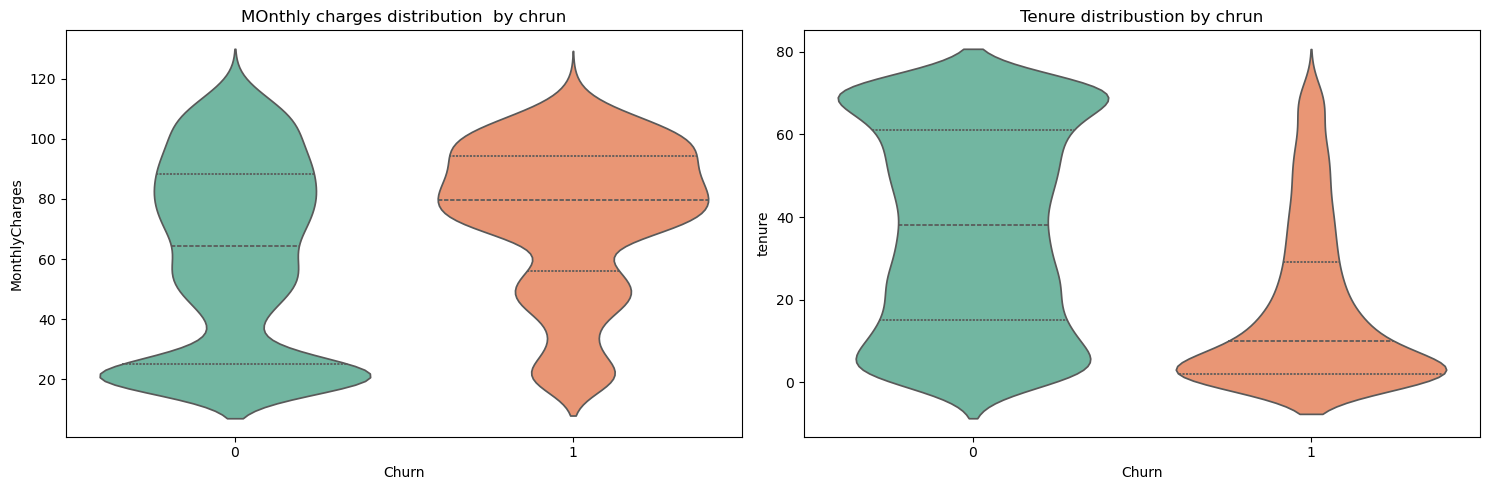

In [103]:

plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
sns.violinplot(data = df,x='Churn',y='MonthlyCharges',palette = 'Set2',inner = 'quartile')
plt.title ('MOnthly charges distribution  by chrun')


plt.subplot(1,2,2)
sns.violinplot(data = df ,x='Churn',y='tenure',palette='Set2',inner = 'quartile')
plt.title('Tenure distribustion by chrun')
plt.tight_layout()
plt.show()


In [104]:
# MonthlyCharges ka 75th percentile (Q3 threshold) nikalenge
q3_charge = df['MonthlyCharges'].quantile(0.75)

# High Value Customers ko isolate karenge
df['High_Value_Customer'] = df['MonthlyCharges'] >= q3_charge
hvc_df = df[df['High_Value_Customer'] == True]


In [105]:
print(type(plt.title))
print(type(hvc_df))
print(hvc_df.columns.tolist())


<class 'function'>
<class 'pandas.core.frame.DataFrame'>
['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'TotalServices', 'Tenure_Group', 'Relationship_status', 'Streaming_Fanatic', 'High_Value_Customer']


In [106]:
q3_charge = df['MonthlyCharges'].quantile(0.75)

df['Heigh_value_costumer'] = df['MonthlyCharges']>= q3_charge
hvc_df = df[df['Heigh_value_costumer']==True]
print(q3_charge)


89.85


In [107]:
import sys
# Agar matplotlib pehle se memory mein hai, toh use clear kar do
if 'matplotlib.pyplot' in sys.modules:
    del sys.modules['matplotlib.pyplot']
    
# Dobara fresh matplotlib import karo
import matplotlib.pyplot as plt
print("Matplotlib reset ho gaya hai! Ab error nahi aayega.")


Matplotlib reset ho gaya hai! Ab error nahi aayega.


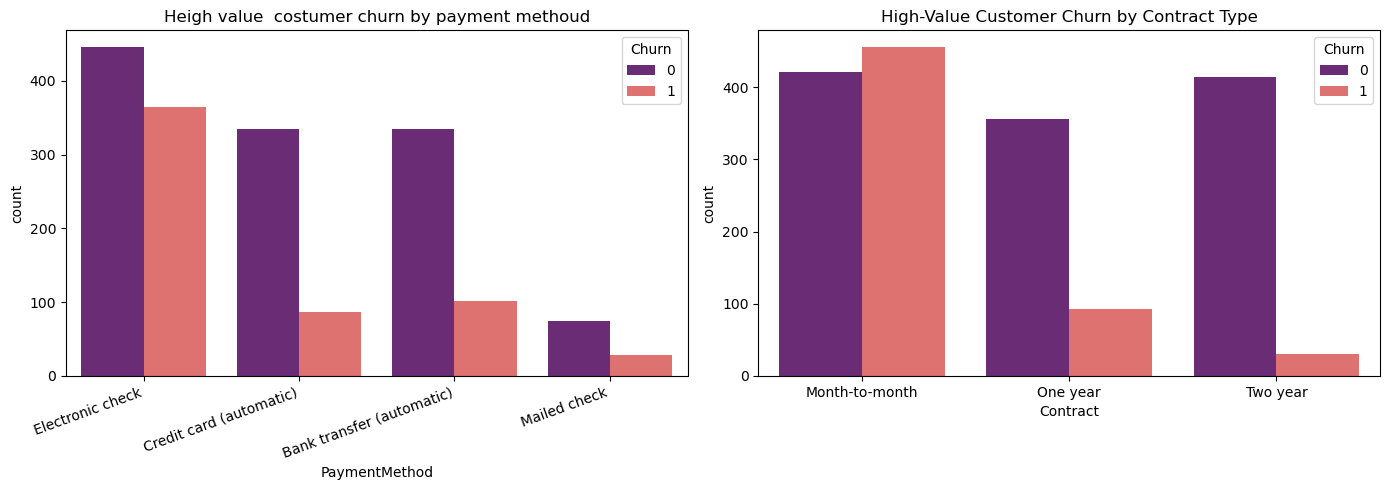

High-Value Customer threshold is Monthly Charge >= $89.85
High-Value Customer Churn Rate:
Churn
0    67.250141
1    32.749859
Name: proportion, dtype: float64


In [108]:
plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
sns.countplot(data = hvc_df,x='PaymentMethod',hue = 'Churn',palette='magma')
plt.title('Heigh value  costumer churn by payment methoud')
plt .xticks(rotation = 20, ha = 'right')

plt.subplot(1, 2, 2)
sns.countplot(data=hvc_df, x='Contract', hue='Churn', palette='magma')
plt.title('High-Value Customer Churn by Contract Type')
plt.tight_layout()
plt.show()
print(f"High-Value Customer threshold is Monthly Charge >= ${q3_charge:.2f}")
print("High-Value Customer Churn Rate:")
print(hvc_df['Churn'].value_counts(normalize=True) * 100)


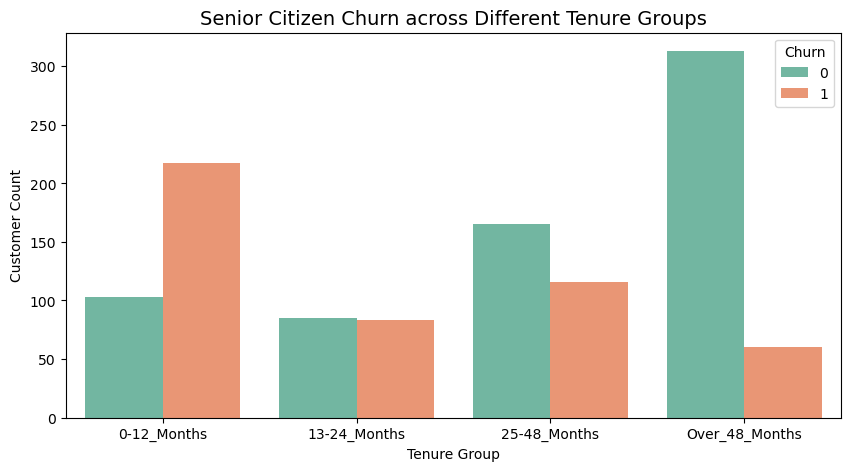

In [109]:
plt.figure(figsize=(10,5))
sns.countplot(data=df[df['SeniorCitizen']==1], x='Tenure_Group', hue='Churn', palette='Set2',
              order=['0-12_Months','13-24_Months','25-48_Months','Over_48_Months'])

plt.title('Senior Citizen Churn across Different Tenure Groups', fontsize=14)
plt.xlabel('Tenure Group')
plt.ylabel('Customer Count')
plt.show()
plt.show()


In [110]:

df['MultipleLines'] = df['MultipleLines'].replace('No phone service', 'No')
df['MultipleLines'] = df['MultipleLines'].map({'Yes':1,"No":0})


In [111]:

pd.crosstab(df['InternetService'],df['Churn'],normalize =  'index')*100


Churn,0,1
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


In [112]:
df_encoded = pd.get_dummies(df,columns=['InternetService'],drop_first= True)


In [113]:
# 1. Pehle automatic payment ka column banayein (Aapki ye line)
df['is_Autometic_payment'] = df['PaymentMethod'].str.contains('automatic').astype(int)

# 2. Phir high-risk check ka column banayein
df['Is_Electronic_Check'] = (df['PaymentMethod'] == 'Electronic check').astype(int)

# 3. Sabse aakhir mein original column ko drop karein
df.drop('PaymentMethod', axis=1, inplace=True)


In [114]:

print(df['is_Autometic_payment'].value_counts())
print(df['is_Autometic_payment'].dtype)  # int64 aayega
df.head()



is_Autometic_payment
0    3977
1    3066
Name: count, dtype: int64
int32


,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,TotalServices,Tenure_Group,Relationship_status,Streaming_Fanatic,High_Value_Customer,Heigh_value_costumer,is_Autometic_payment,Is_Electronic_Check
0,0,1,0,1,0,0,DSL,No,Yes,No,No,No,No,Month-to-month,1,29.85,29.85,0,1,0-12_Months,Partner Only,Regular/Non-User,False,False,0,1
1,0,0,0,34,1,0,DSL,Yes,No,Yes,No,No,No,One year,0,56.95,1889.50,0,3,25-48_Months,solo,Regular/Non-User,False,False,0,0
2,0,0,0,2,1,0,DSL,Yes,Yes,No,No,No,No,Month-to-month,1,53.85,108.15,1,3,0-12_Months,solo,Regular/Non-User,False,False,0,0
3,0,0,0,45,0,0,DSL,Yes,No,Yes,Yes,No,No,One year,0,42.30,1840.75,0,3,25-48_Months,solo,Regular/Non-User,False,False,1,0
4,0,0,0,2,1,0,Fiber optic,No,No,No,No,No,No,Month-to-month,1,70.70,151.65,1,1,0-12_Months,solo,Regular/Non-User,False,False,0,1


In [115]:
pd.crosstab(df['OnlineSecurity'],df['Churn'],normalize='index')*100


df['OnlineSecurity'] = df['OnlineSecurity'].map({
    'Yes': 1,
    'No': 0,
    'No internet service': 0
})


In [116]:
import pandas as pd

# Saare columns dekhne ke liye setting
pd.set_option('display.max_columns', None)

# (Optional) Agar kabhi saare rows dekhne hon to:
# pd.set_option('display.max_rows', None)


df.head()
df.drop('Heigh_value_costumer',axis=1,inplace=True)


In [117]:
service_cols = ['OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
for col in service_cols:
    df[col] = (df[col] == 'Yes').astype(int)



In [118]:
df['Contract'] = df['Contract'].map({'Month-to-month': 0, 'One year': 1, 'Two year': 2})


In [119]:
# Pehle boolean / string check
df['Streaming_Fanatic'] = (df['Streaming_Fanatic'] == 'Fanatic').astype(int)
df['High_Value_Customer'] = df['High_Value_Customer'].astype(int)

# Relationship_status aur Tenure_Group ke dummy variables banana
df = pd.get_dummies(df, columns=['Relationship_status', 'Tenure_Group'], drop_first=True)


In [120]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 28 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   SeniorCitizen                     7043 non-null   int64  
 1   Partner                           7043 non-null   int64  
 2   Dependents                        7043 non-null   int64  
 3   tenure                            7043 non-null   int64  
 4   PhoneService                      7043 non-null   int64  
 5   MultipleLines                     7043 non-null   int64  
 6   InternetService                   7043 non-null   object 
 7   OnlineSecurity                    7043 non-null   int64  
 8   OnlineBackup                      7043 non-null   int32  
 9   DeviceProtection                  7043 non-null   int32  
 10  TechSupport                       7043 non-null   int32  
 11  StreamingTV                       7043 non-null   int32  
 12  Stream

In [121]:
# 1. Bug 3 Fix (Apply dummy encoding to main df)
df = pd.get_dummies(df, columns=['InternetService'], drop_first=True)

# 2. Bug 2 Fix (Robust streaming fanatic logic)
df['Streaming_Fanatic'] = (((df['StreamingTV'] == 'Yes') | (df['StreamingTV'] == 1)) & 
                             ((df['StreamingMovies'] == 'Yes') | (df['StreamingMovies'] == 1))).astype(int)

# 3. Bug 1 Fix (Drop redundant column)
if 'Is_Electronic_Check' in df.columns:
    df.drop('Is_Electronic_Check', axis=1, inplace=True)

# 4. Clean duplicate High Value Customer column (Jo correlation heatmap mein mila tha)
if 'Heigh_value_costumer' in df.columns:
    df.drop('Heigh_value_costumer', axis=1, inplace=True)

# 5. Final check
print(df.info())
print("Missing values:", df.isnull().sum().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 28 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   SeniorCitizen                     7043 non-null   int64  
 1   Partner                           7043 non-null   int64  
 2   Dependents                        7043 non-null   int64  
 3   tenure                            7043 non-null   int64  
 4   PhoneService                      7043 non-null   int64  
 5   MultipleLines                     7043 non-null   int64  
 6   OnlineSecurity                    7043 non-null   int64  
 7   OnlineBackup                      7043 non-null   int32  
 8   DeviceProtection                  7043 non-null   int32  
 9   TechSupport                       7043 non-null   int32  
 10  StreamingTV                       7043 non-null   int32  
 11  StreamingMovies                   7043 non-null   int32  
 12  Contra

<function matplotlib.pyplot.show(close=None, block=None)>

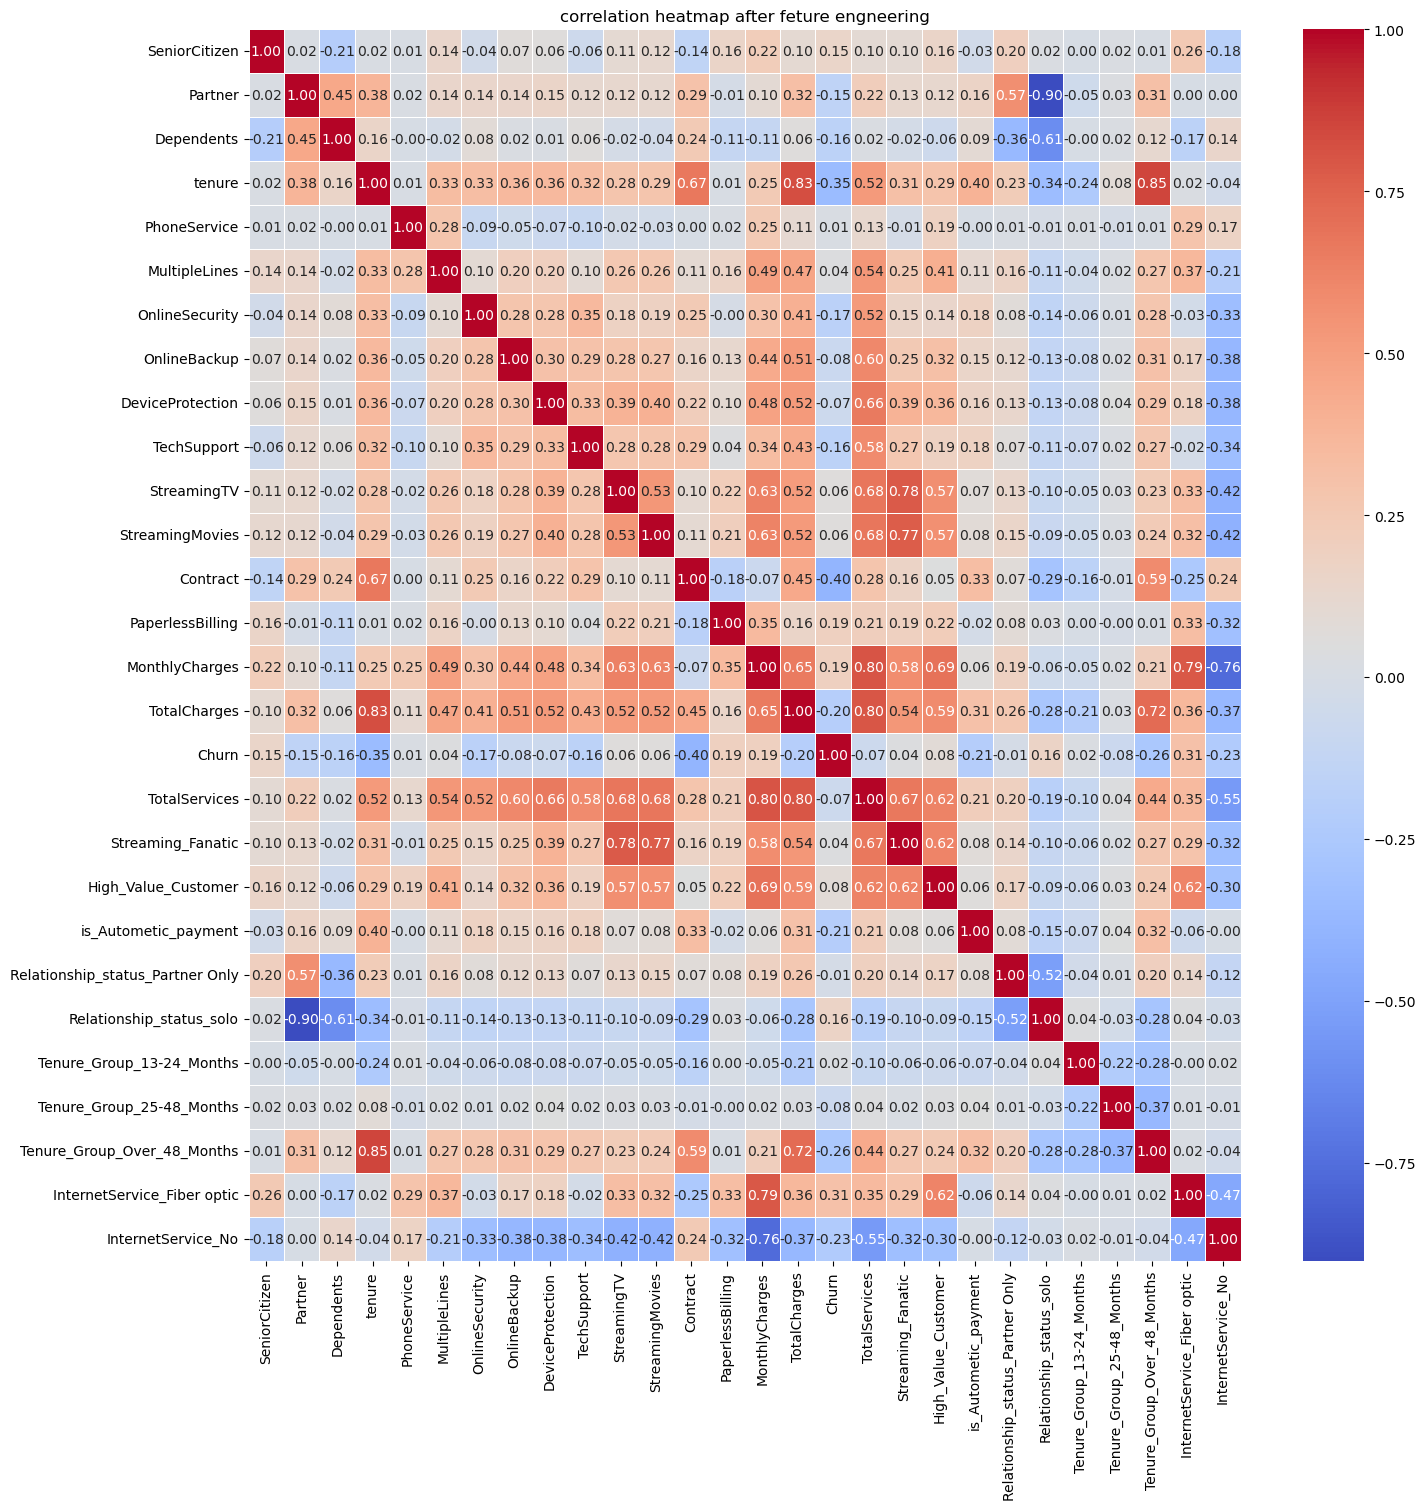

In [122]:
numrical_df = df.select_dtypes(include=['number',"bool"])

corr_matrix  = numrical_df.corr()
plt.figure(figsize=(16,16))
sns.heatmap(corr_matrix,annot = True,cmap='coolwarm',fmt='.2f',linewidths=0.5)
plt.title("correlation heatmap after feture engneering")
plt.show


In [123]:
df.head()


,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,TotalServices,Streaming_Fanatic,High_Value_Customer,is_Autometic_payment,Relationship_status_Partner Only,Relationship_status_solo,Tenure_Group_13-24_Months,Tenure_Group_25-48_Months,Tenure_Group_Over_48_Months,InternetService_Fiber optic,InternetService_No
0,0,1,0,1,0,0,0,1,0,0,0,0,0,1,29.85,29.85,0,1,0,0,0,True,False,False,False,False,False,False
1,0,0,0,34,1,0,1,0,1,0,0,0,1,0,56.95,1889.50,0,3,0,0,0,False,True,False,True,False,False,False
2,0,0,0,2,1,0,1,1,0,0,0,0,0,1,53.85,108.15,1,3,0,0,0,False,True,False,False,False,False,False
3,0,0,0,45,0,0,1,0,1,1,0,0,1,0,42.30,1840.75,0,3,0,0,1,False,True,False,True,False,False,False
4,0,0,0,2,1,0,0,0,0,0,0,0,0,1,70.70,151.65,1,1,0,0,0,False,True,False,False,False,True,False


In [124]:
# Jo features aapne select kiye hain unki list
selected_features = [
    'Contract', 
    'tenure', 
    'MonthlyCharges', 
    'InternetService_No', 
    'InternetService_Fiber optic', 
    'OnlineSecurity', 
    'TechSupport', 
    'PaperlessBilling', 
    'SeniorCitizen', 
    'is_Autometic_payment', 
    'Churn'  # Target column
]

# Naya final dataframe create karein jo model ke liye bilkul ready hai
df_final = df[selected_features]

# Final check
print(df_final.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Contract                     7043 non-null   int64  
 1   tenure                       7043 non-null   int64  
 2   MonthlyCharges               7043 non-null   float64
 3   InternetService_No           7043 non-null   bool   
 4   InternetService_Fiber optic  7043 non-null   bool   
 5   OnlineSecurity               7043 non-null   int64  
 6   TechSupport                  7043 non-null   int32  
 7   PaperlessBilling             7043 non-null   int64  
 8   SeniorCitizen                7043 non-null   int64  
 9   is_Autometic_payment         7043 non-null   int32  
 10  Churn                        7043 non-null   int64  
dtypes: bool(2), float64(1), int32(2), int64(6)
memory usage: 454.1 KB
None


In [ ]:
X = df_final.drop('Churn',axis=1)
Y = df_final['Churn']


X_train,X_test,Y_train,Y_test  = train_test_split(X,Y,test_size=0.2,random_state=42,stratify=Y)




In [126]:
print(X_test)


      Contract  tenure  MonthlyCharges  InternetService_No  \
437          2      72          114.05               False   
2280         0       8          100.15               False   
2235         1      41           78.35               False   
4460         0      18           78.20               False   
3761         2      72           82.65               False   
...        ...     ...             ...                 ...   
5143         1      49           87.20               False   
4439         2      28           20.30                True   
3857         0       5           20.65                True   
4758         2      56           19.70                True   
5613         2      72           70.45               False   

      InternetService_Fiber optic  OnlineSecurity  TechSupport  \
437                          True               1            1   
2280                         True               0            1   
2235                        False               1        

In [127]:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)


In [ ]:

model = LogisticRegression(class_weight='balanced',random_state=42)
model.fit(X_train_scaled,Y_train)


LogisticRegression(class_weight='balanced', random_state=42)

In [129]:
Y_pred = model.predict(X_test_scaled)
Y_pred_prob  = model.predict_proba(X_test_scaled)[:,1]


print("confusion martrix")
print(confusion_matrix(Y_test,Y_pred))

print("\n --- classification Report")
print(classification_report(Y_test,Y_pred))

print(f"roc_auc_score: {roc_auc_score(Y_test,Y_pred_prob):.4f}")


confusion martrix
[[732 303]
 [ 78 296]]

 --- classification Report
              precision    recall  f1-score   support

           0       0.90      0.71      0.79      1035
           1       0.49      0.79      0.61       374

    accuracy                           0.73      1409
   macro avg       0.70      0.75      0.70      1409
weighted avg       0.79      0.73      0.74      1409

roc_auc_score: 0.8345


In [ ]:
rf_model = RandomForestClassifier(class_weight='balanced',random_state=42)
rf_model.fit(X_train,Y_train)


RandomForestClassifier(class_weight='balanced', random_state=42)

In [134]:
Y_pred_rf = rf_model.predict(X_test)
Y_pred_prob_rf  = rf_model.predict_proba(X_test)[:,1]


In [158]:
print(" randomforest confusion metrix")
print(confusion_matrix(Y_test,Y_pred_rf))
print("\nrandom forest classifiction report")
print(classification_report(Y_test,Y_pred_rf))
print(f'ROC-AUCScore:{roc_auc_score(Y_test,Y_pred_prob_rf):.4f}')

# Default Random Forest ke train set ka score check karein
y_train_pred_default = rf_model.predict(X_train)

print("=== Train Classification Report (Default RF) ===")
print(classification_report(Y_train, y_train_pred_default))



 randomforest confusion metrix
[[907 128]
 [190 184]]

random forest classifiction report
              precision    recall  f1-score   support

           0       0.83      0.88      0.85      1035
           1       0.59      0.49      0.54       374

    accuracy                           0.77      1409
   macro avg       0.71      0.68      0.69      1409
weighted avg       0.76      0.77      0.77      1409

ROC-AUCScore:0.8101
=== Train Classification Report (Default RF) ===
              precision    recall  f1-score   support

           0       1.00      0.99      1.00      4139
           1       0.98      1.00      0.99      1495

    accuracy                           0.99      5634
   macro avg       0.99      0.99      0.99      5634
weighted avg       0.99      0.99      0.99      5634



In [ ]:
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train,Y_train)


GradientBoostingClassifier(random_state=42)

In [142]:
Y_pred_gb  = gb_model.predict(X_test)
Y_pred_prob_gb = gb_model.predict_proba(X_test)[:,1]



In [160]:
print("gredient boost confusion metrixs")
print(confusion_matrix(Y_test,Y_pred_gb))

print("\n gradient boosting classifictaion report")
print(classification_report(Y_test,Y_pred_gb))

print(f"ROC-AUC Score:{roc_auc_score(Y_test,Y_pred_prob_gb):.4f}")


# Default Random Forest ke train set ka score check karein
y_train_pred_default = gb_model.predict(X_train)

print("=== Train Classification Report (Default gb) ===")
print(classification_report(Y_train, y_train_pred_default))



gredient boost confusion metrixs
[[926 109]
 [182 192]]

 gradient boosting classifictaion report
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.64      0.51      0.57       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.78      0.79      0.79      1409

ROC-AUC Score:0.8423
=== Train Classification Report (Default gb) ===
              precision    recall  f1-score   support

           0       0.85      0.91      0.88      4139
           1       0.70      0.56      0.62      1495

    accuracy                           0.82      5634
   macro avg       0.78      0.74      0.75      5634
weighted avg       0.81      0.82      0.81      5634



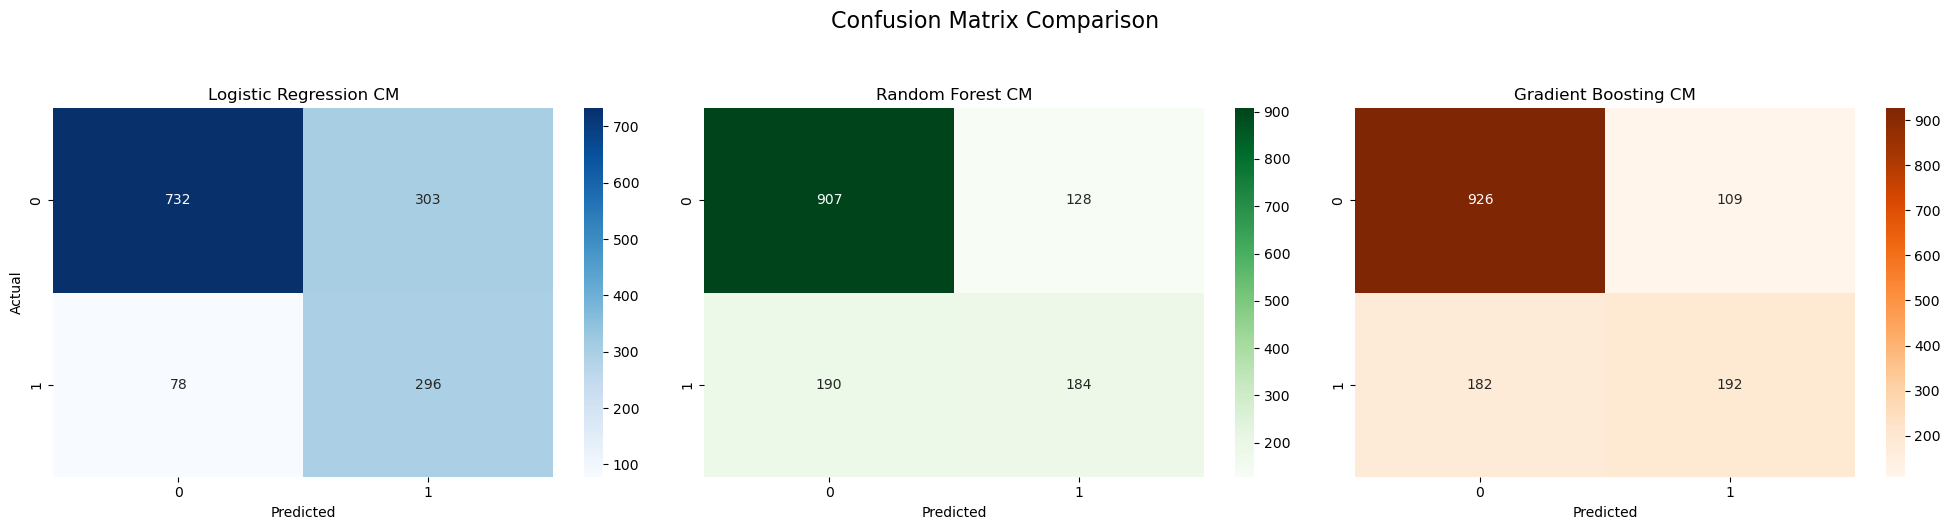

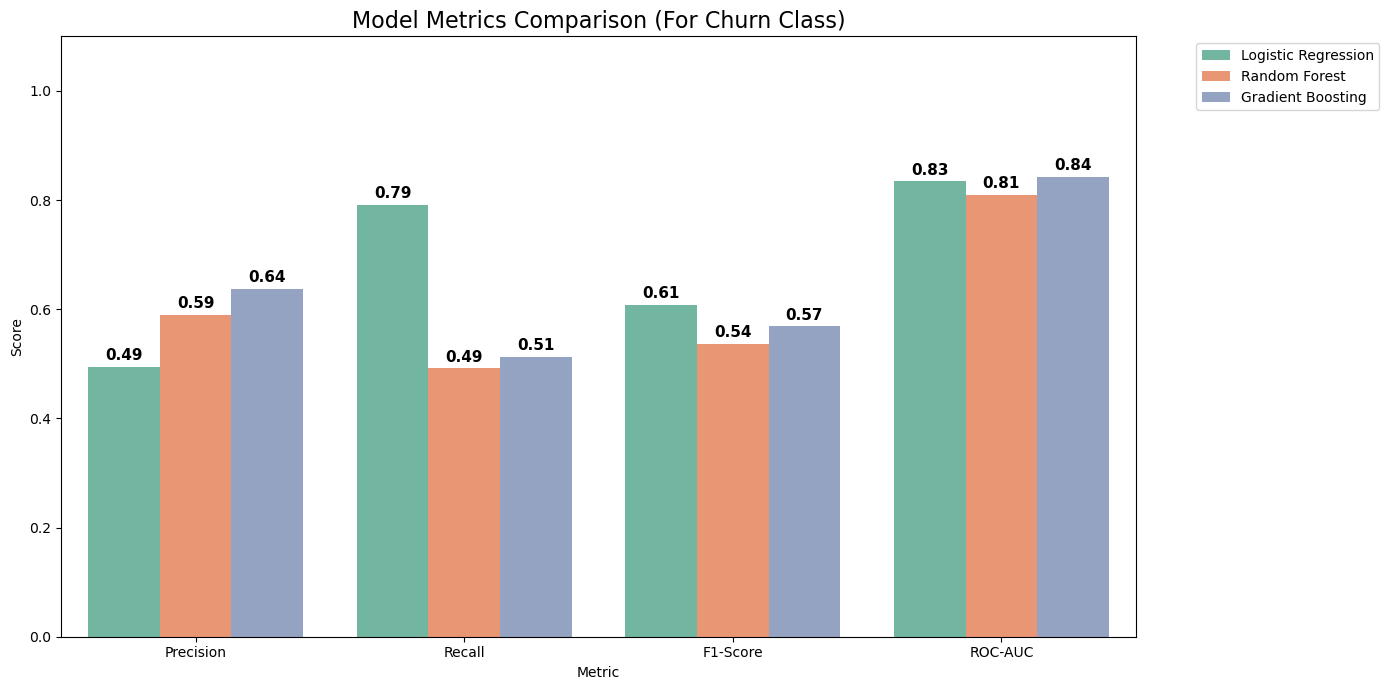

In [161]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score

# ==========================================
# 1. Model Training (Same names for all variables)
# ==========================================

# Logistic Regression (Scaled data)
lr_model = LogisticRegression(class_weight='balanced', random_state=42)
lr_model.fit(X_train_scaled, Y_train)
y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

# Random Forest (Unscaled data)
rf_model = RandomForestClassifier(class_weight='balanced', random_state=42)
rf_model.fit(X_train, Y_train)
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Gradient Boosting (Unscaled data)
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, Y_train)
y_pred_gb = gb_model.predict(X_test)
y_prob_gb = gb_model.predict_proba(X_test)[:, 1]


# ==========================================
# 2. Plotting Confusion Matrices Side-by-Side (plt.subplots fix)
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(20, 5)) # 'plt.subplots' use kiya (with 's')

# Logistic Regression Heatmap
sns.heatmap(confusion_matrix(Y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title("Logistic Regression CM")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# Random Forest Heatmap
sns.heatmap(confusion_matrix(Y_test, y_pred_rf), annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title("Random Forest CM")
axes[1].set_xlabel("Predicted")

# Gradient Boosting Heatmap
sns.heatmap(confusion_matrix(Y_test, y_pred_gb), annot=True, fmt='d', cmap='Oranges', ax=axes[2])
axes[2].set_title("Gradient Boosting CM")
axes[2].set_xlabel("Predicted")

plt.suptitle("Confusion Matrix Comparison", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()


# ==========================================
# 3. Metrics Comparison Plot (Using consistent variables)
# ==========================================
models = ['Logistic Regression', 'Random Forest', 'Gradient Boosting']

# Metrics for Churn (Class 1) using Y_test and correct prediction variables
precision_scores = [precision_score(Y_test, y_pred_lr), precision_score(Y_test, y_pred_rf), precision_score(Y_test, y_pred_gb)]
recall_scores = [recall_score(Y_test, y_pred_lr), recall_score(Y_test, y_pred_rf), recall_score(Y_test, y_pred_gb)]
f1_scores = [f1_score(Y_test, y_pred_lr), f1_score(Y_test, y_pred_rf), f1_score(Y_test, y_pred_gb)]
roc_auc_scores = [roc_auc_score(Y_test, y_prob_lr), roc_auc_score(Y_test, y_prob_rf), roc_auc_score(Y_test, y_prob_gb)]

# Create a comparison DataFrame
metrics_df = pd.DataFrame({
    'Model': models * 4,
    'Metric': ['Precision']*3 + ['Recall']*3 + ['F1-Score']*3 + ['ROC-AUC']*3,
    'Score': precision_scores + recall_scores + f1_scores + roc_auc_scores
})

# Plot Bar Chart
plt.figure(figsize=(14, 7))
ax = sns.barplot(data=metrics_df, x='Metric', y='Score', hue='Model', palette='Set2')
plt.title("Model Metrics Comparison (For Churn Class)", fontsize=16)
plt.ylim(0, 1.1)
plt.ylabel("Score")

# Add values on top of bars
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f"{p.get_height():.2f}", 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', xytext=(0, 8), 
                    textcoords='offset points', fontsize=11, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [157]:
# Default Random Forest ke train set ka score check karein
y_train_pred_default = rf_model.predict(X_train)

print("=== Train Classification Report (Default RF) ===")
print(classification_report(Y_train, y_train_pred_default))


=== Train Classification Report (Default RF) ===
              precision    recall  f1-score   support

           0       1.00      0.99      1.00      4139
           1       0.98      1.00      0.99      1495

    accuracy                           0.99      5634
   macro avg       0.99      0.99      0.99      5634
weighted avg       0.99      0.99      0.99      5634



In [163]:
import joblib

# Gradient Boosting model save karo
joblib.dump(gb_model, 'churn_model.pkl')

print("Model saved successfully!")


Model saved successfully!


In [ ]:
df.head()


,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,TotalServices,Streaming_Fanatic,High_Value_Customer,is_Autometic_payment,Relationship_status_Partner Only,Relationship_status_solo,Tenure_Group_13-24_Months,Tenure_Group_25-48_Months,Tenure_Group_Over_48_Months,InternetService_Fiber optic,InternetService_No
0,0,1,0,1,0,0,0,1,0,0,0,0,0,1,29.85,29.85,0,1,0,0,0,True,False,False,False,False,False,False
1,0,0,0,34,1,0,1,0,1,0,0,0,1,0,56.95,1889.50,0,3,0,0,0,False,True,False,True,False,False,False
2,0,0,0,2,1,0,1,1,0,0,0,0,0,1,53.85,108.15,1,3,0,0,0,False,True,False,False,False,False,False
3,0,0,0,45,0,0,1,0,1,1,0,0,1,0,42.30,1840.75,0,3,0,0,1,False,True,False,True,False,False,False
4,0,0,0,2,1,0,0,0,0,0,0,0,0,1,70.70,151.65,1,1,0,0,0,False,True,False,False,False,True,False
